# 01 Generative AI Introduction

## 📚 Learning Objectives

By completing this notebook, you will:
- Define generative AI and typical applications
- Identify model types (GANs, VAEs, LMs) and trade-offs

## 🔗 Where this fits

**Builds on:** Unit 1, lesson 11 "Introduction to Generative AI" — the same map of GANs, VAEs and language models, now that you have trained networks yourself.

**Used later in:** Course 10 (AIAT 124) — Unit 1, which implements every model family named here.

---


# 01 Generative AI Introduction

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand what generative AI is and its importance
- Learn about the evolution of generative AI
- Explore key applications and real-world use cases
- Understand the relationship between generative AI and other AI approaches

## 🔗 Prerequisites

- ✅ Completed Units 1-4
- ✅ Understanding of neural networks
- ✅ Basic Python knowledge

---

## Real-World Context

Generative AI is transforming industries:
- **Content Creation**: AI-generated images, videos, and music
- **Healthcare**: Drug discovery and medical image synthesis
- **Entertainment**: Game asset generation and virtual worlds
- **Business**: Synthetic data generation for training models

This notebook introduces you to the exciting world of generative AI!


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

Example 1: Introduction to Generative AI

1. What is Generative AI?

Generative AI refers to artificial intelligence systems that can create new content, including text, images, audio, video, and other data types.

Key Characteristics:
- Creates NEW content (not just classification or prediction)
- Learns patterns from training data
- Generates novel outputs based on learned patterns
- Can produce diverse and creative outputs


2. Evolution of Generative AI
2014: GANs (Generative Adversarial Networks) introduced
2015: VAEs (Variational Autoencoders) become popular
2017: Transformer architecture revolutionizes NLP
2019: GPT-2 demonstrates impressive text generation
2020: GPT-3 shows few-shot learning capabilities
2021: DALL-E generates images from text
2022: ChatGPT and Stable Diffusion bring generative AI to mainstream
2023: GPT-4 and multimodal models advance the field

3. Key Applications of Generative AI

Text Generation:
  • Creative writing
  • Code generation
  • Translation
  • 

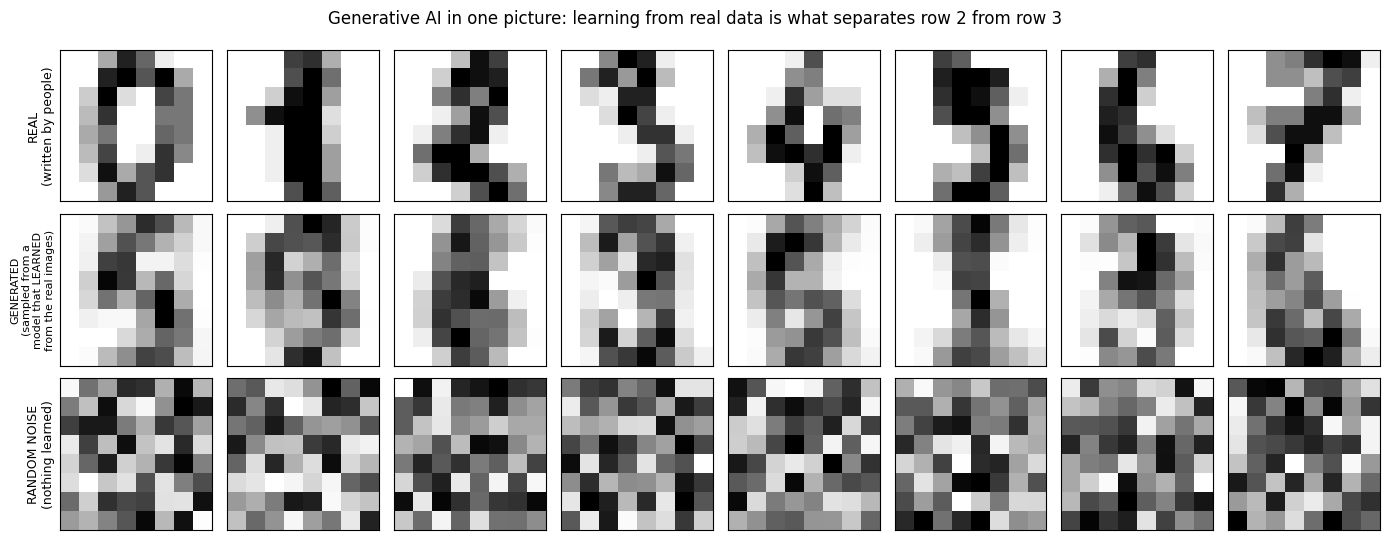


Distance to the nearest REAL digit (lower = more digit-like):
  Generated samples (model learned from data):  22.65
  Uniform random noise (nothing learned)     :  56.57

✅ Row 2 was produced by a model that LEARNED the shape of real handwriting
   and then sampled new examples from what it learned. That is the definition of
   generative AI at work — no one wrote a formula for the digit '3'.

⚠️  Honest caveat: PCA is a very weak generative model. Its samples are blurry
   averages, because it can only mix directions of variation linearly. Modern
   generative models (GANs, VAEs, diffusion) learn far richer distributions.
   You will train a GAN on real data in 04_simple_gan_experiment.ipynb.

5. Key Takeaways
1. Generative AI creates NEW content, not just predictions
2. Creating data is only 'generative AI' if the pattern was LEARNED from data — the PCA digit sampler above learned from 1,797 real handwritten images; the uniform-noise row learned nothing and looks like it
3. It learn

In [1]:
# What 'generative AI' means: the definition, ten years of evolution, the application
# landscape, and a first working generative model trained on REAL handwritten digits.
# This framing prepares you for the GAN experiment later in this unit.
"""
Unit 5 - Example 1: Introduction to Generative AI

This example demonstrates:
1. Understanding generative AI concepts
2. Historical evolution
3. Key applications
4. Real-world examples
"""

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

print("=" * 70)
print("Example 1: Introduction to Generative AI")
print("=" * 70)

# 1. What is Generative AI?
print("\n" + "=" * 70)
print("1. What is Generative AI?")
print("=" * 70)

# The working definition: systems that CREATE new content by learning patterns from data.
generative_ai_definition = """
Generative AI refers to artificial intelligence systems that can create new content, including text, images, audio, video, and other data types.

Key Characteristics:
- Creates NEW content (not just classification or prediction)
- Learns patterns from training data
- Generates novel outputs based on learned patterns
- Can produce diverse and creative outputs
"""

print(generative_ai_definition)

# 2. Evolution Timeline
print("\n" + "=" * 70)
print("2. Evolution of Generative AI")
print("=" * 70)

# A decade of breakthroughs: from GANs (2014) to multimodal models (2023).
timeline = {
    "2014": "GANs (Generative Adversarial Networks) introduced", "2015": "VAEs (Variational Autoencoders) become popular",
    "2017": "Transformer architecture revolutionizes NLP",
    "2019": "GPT-2 demonstrates impressive text generation",
    "2020": "GPT-3 shows few-shot learning capabilities",
    "2021": "DALL-E generates images from text",
    "2022": "ChatGPT and Stable Diffusion bring generative AI to mainstream",
    "2023": "GPT-4 and multimodal models advance the field"
}

for year, event in timeline.items():
    print(f"{year}: {event}")

# 3. Key Applications
print("\n" + "=" * 70)
print("3. Key Applications of Generative AI")
print("=" * 70)

# Five content types generative models can produce, each with concrete use cases.
applications = {
    "Text Generation": [
        "Creative writing", "Code generation",
        "Translation",
        "Summarization",
        "Chatbots and virtual assistants"
    ],
    "Image Generation": [
        "Art creation",
        "Product design",
        "Medical imaging",
        "Game assets",
        "Photo editing"
    ],
    "Audio Generation": [
        "Music composition",
        "Voice synthesis",
        "Sound effects",
        "Podcast generation"
    ],
    "Video Generation": [
        "Video editing",
        "Animation",
        "Virtual reality content",
        "Training simulations"
    ],
    "Data Generation": [
        "Synthetic datasets",
        "Data augmentation",
        "Privacy-preserving data",
        "Testing data"
    ]
}

for category, examples in applications.items():
    print(f"\n{category}:")
    for example in examples:
        print(f"  • {example}")

# 4. A first REAL generative model, trained on REAL handwritten digits
print("\n" + "=" * 70)
print("4. A First Generative Model, Learned From Real Handwritten Digits")
print("=" * 70)

# REAL DATA: 1,797 handwritten digit images collected from 43 people for the UCI
# "Optical Recognition of Handwritten Digits" study. Each image is 8x8 greyscale.
# Nobody invented these pixels — real hands wrote these digits.
digits = load_digits()
X_digits = digits.data          # shape (1797, 64): one row per image, 64 pixel values
print(f"\nReal dataset: UCI handwritten digits")
print(f"  {X_digits.shape[0]:,} real images, each {int(np.sqrt(X_digits.shape[1]))}x{int(np.sqrt(X_digits.shape[1]))} pixels")
print(f"  Written by 43 real people; pixel values run 0-16 (greyscale)")

# LEARN the distribution. PCA finds the 20 directions along which real digits actually
# vary, and tells us how much they vary along each one. That IS a learned model of
# "what a handwritten digit looks like" — we never wrote a formula for a digit.
N_COMPONENTS = 20
pca = PCA(n_components=N_COMPONENTS, random_state=42)
Z_real = pca.fit_transform(X_digits)     # real images projected into 20 learned dimensions
print(f"\n  Learned {N_COMPONENTS} components; they capture "
      f"{pca.explained_variance_ratio_.sum() * 100:.1f}% of the real variation in the images")

# GENERATE. We sample brand-new points from the distribution PCA LEARNED (each learned
# direction gets its own learned standard deviation), then decode them back into pixels.
# Randomness here IS the lesson: sampling is how a generative model produces novel output.
rng = np.random.default_rng(42)
learned_std = Z_real.std(axis=0)                       # learned spread per direction
Z_new = rng.normal(0.0, learned_std, size=(8, N_COMPONENTS))
X_generated = pca.inverse_transform(Z_new)             # decode latent samples into images

# A control condition: pure uniform noise over the same pixel range, with NO learning.
X_noise = rng.uniform(0, 16, size=(8, X_digits.shape[1]))

fig, axes = plt.subplots(3, 8, figsize=(14, 5.5))
for j in range(8):
    axes[0, j].imshow(X_digits[j].reshape(8, 8), cmap="gray_r")
    axes[1, j].imshow(np.clip(X_generated[j], 0, 16).reshape(8, 8), cmap="gray_r")
    axes[2, j].imshow(X_noise[j].reshape(8, 8), cmap="gray_r")
    for row in range(3):
        axes[row, j].set_xticks([]); axes[row, j].set_yticks([])
axes[0, 0].set_ylabel("REAL\n(written by people)", fontsize=9)
axes[1, 0].set_ylabel("GENERATED\n(sampled from a\nmodel that LEARNED\nfrom the real images)", fontsize=8)
axes[2, 0].set_ylabel("RANDOM NOISE\n(nothing learned)", fontsize=9)
fig.suptitle("Generative AI in one picture: learning from real data is what separates row 2 from row 3",
             fontsize=12)
plt.tight_layout()
plt.show()

# Measure the difference instead of just asserting it: how far is each row from the
# real data, measured by distance to the nearest real image in pixel space?
def mean_distance_to_nearest_real(batch):
    """Average Euclidean distance from each image in `batch` to its closest REAL digit."""
    d = np.linalg.norm(X_digits[None, :, :] - batch[:, None, :], axis=2)
    return d.min(axis=1).mean()

d_generated = mean_distance_to_nearest_real(np.clip(X_generated, 0, 16))
d_noise = mean_distance_to_nearest_real(X_noise)
print(f"\nDistance to the nearest REAL digit (lower = more digit-like):")
print(f"  Generated samples (model learned from data): {d_generated:6.2f}")
print(f"  Uniform random noise (nothing learned)     : {d_noise:6.2f}")

print("\n\u2705 Row 2 was produced by a model that LEARNED the shape of real handwriting")
print("   and then sampled new examples from what it learned. That is the definition of")
print("   generative AI at work \u2014 no one wrote a formula for the digit '3'.")
print("")
print("\u26a0\ufe0f  Honest caveat: PCA is a very weak generative model. Its samples are blurry")
print("   averages, because it can only mix directions of variation linearly. Modern")
print("   generative models (GANs, VAEs, diffusion) learn far richer distributions.")
print("   You will train a GAN on real data in 04_simple_gan_experiment.ipynb.")

# 5. Summary
print("\n" + "=" * 70)
print("5. Key Takeaways")
print("=" * 70)

takeaways = [
    "Generative AI creates NEW content, not just predictions",
    "Creating data is only 'generative AI' if the pattern was LEARNED from data — "
    "the PCA digit sampler above learned from 1,797 real handwritten images; "
    "the uniform-noise row learned nothing and looks like it",
    "It learns patterns from data and generates novel outputs",
    "Applications span text, images, audio, video, and data",
    "It's transforming industries from healthcare to entertainment",
    "Understanding generative AI is crucial for modern AI practitioners"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"{i}. {takeaway}")

print("\n" + "=" * 70)
print("Next: Learn about Generative vs Discriminative Models")
print("=" * 70)

## 📚 References

1. Goodfellow, I., Pouget-Abadie, J., Mirza, M., et al. (2014). *Generative Adversarial Nets*. NeurIPS. <https://arxiv.org/abs/1406.2661>
2. Kingma, D. P., & Welling, M. (2014). *Auto-Encoding Variational Bayes*. ICLR. <https://arxiv.org/abs/1312.6114>
3. Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). *Attention Is All You Need* (Transformer). NeurIPS. <https://arxiv.org/abs/1706.03762>
4. Ho, J., Jain, A., & Abbeel, P. (2020). *Denoising Diffusion Probabilistic Models*. NeurIPS. <https://arxiv.org/abs/2006.11239>
5. Bommasani, R., Hudson, D. A., Adeli, E., et al. (2021). *On the Opportunities and Risks of Foundation Models*. arXiv. <https://arxiv.org/abs/2108.07258>